# **EXPLORATORY DATA ANALYSIS**

## Importing Required Libraries

In [32]:
# DATA HANDLING
import numpy as np
import pandas as pd

# DATA VISUALIZATION
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

##  Loading the Dataset

In [33]:
# ===Load Data===
pd.set_option('display.max_columns', None)
data=pd.read_excel("INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls")

# ===Checking first five rows of dataset===
data.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


##  Exploratory Data Analysis (EDA)

#### CHART - 1

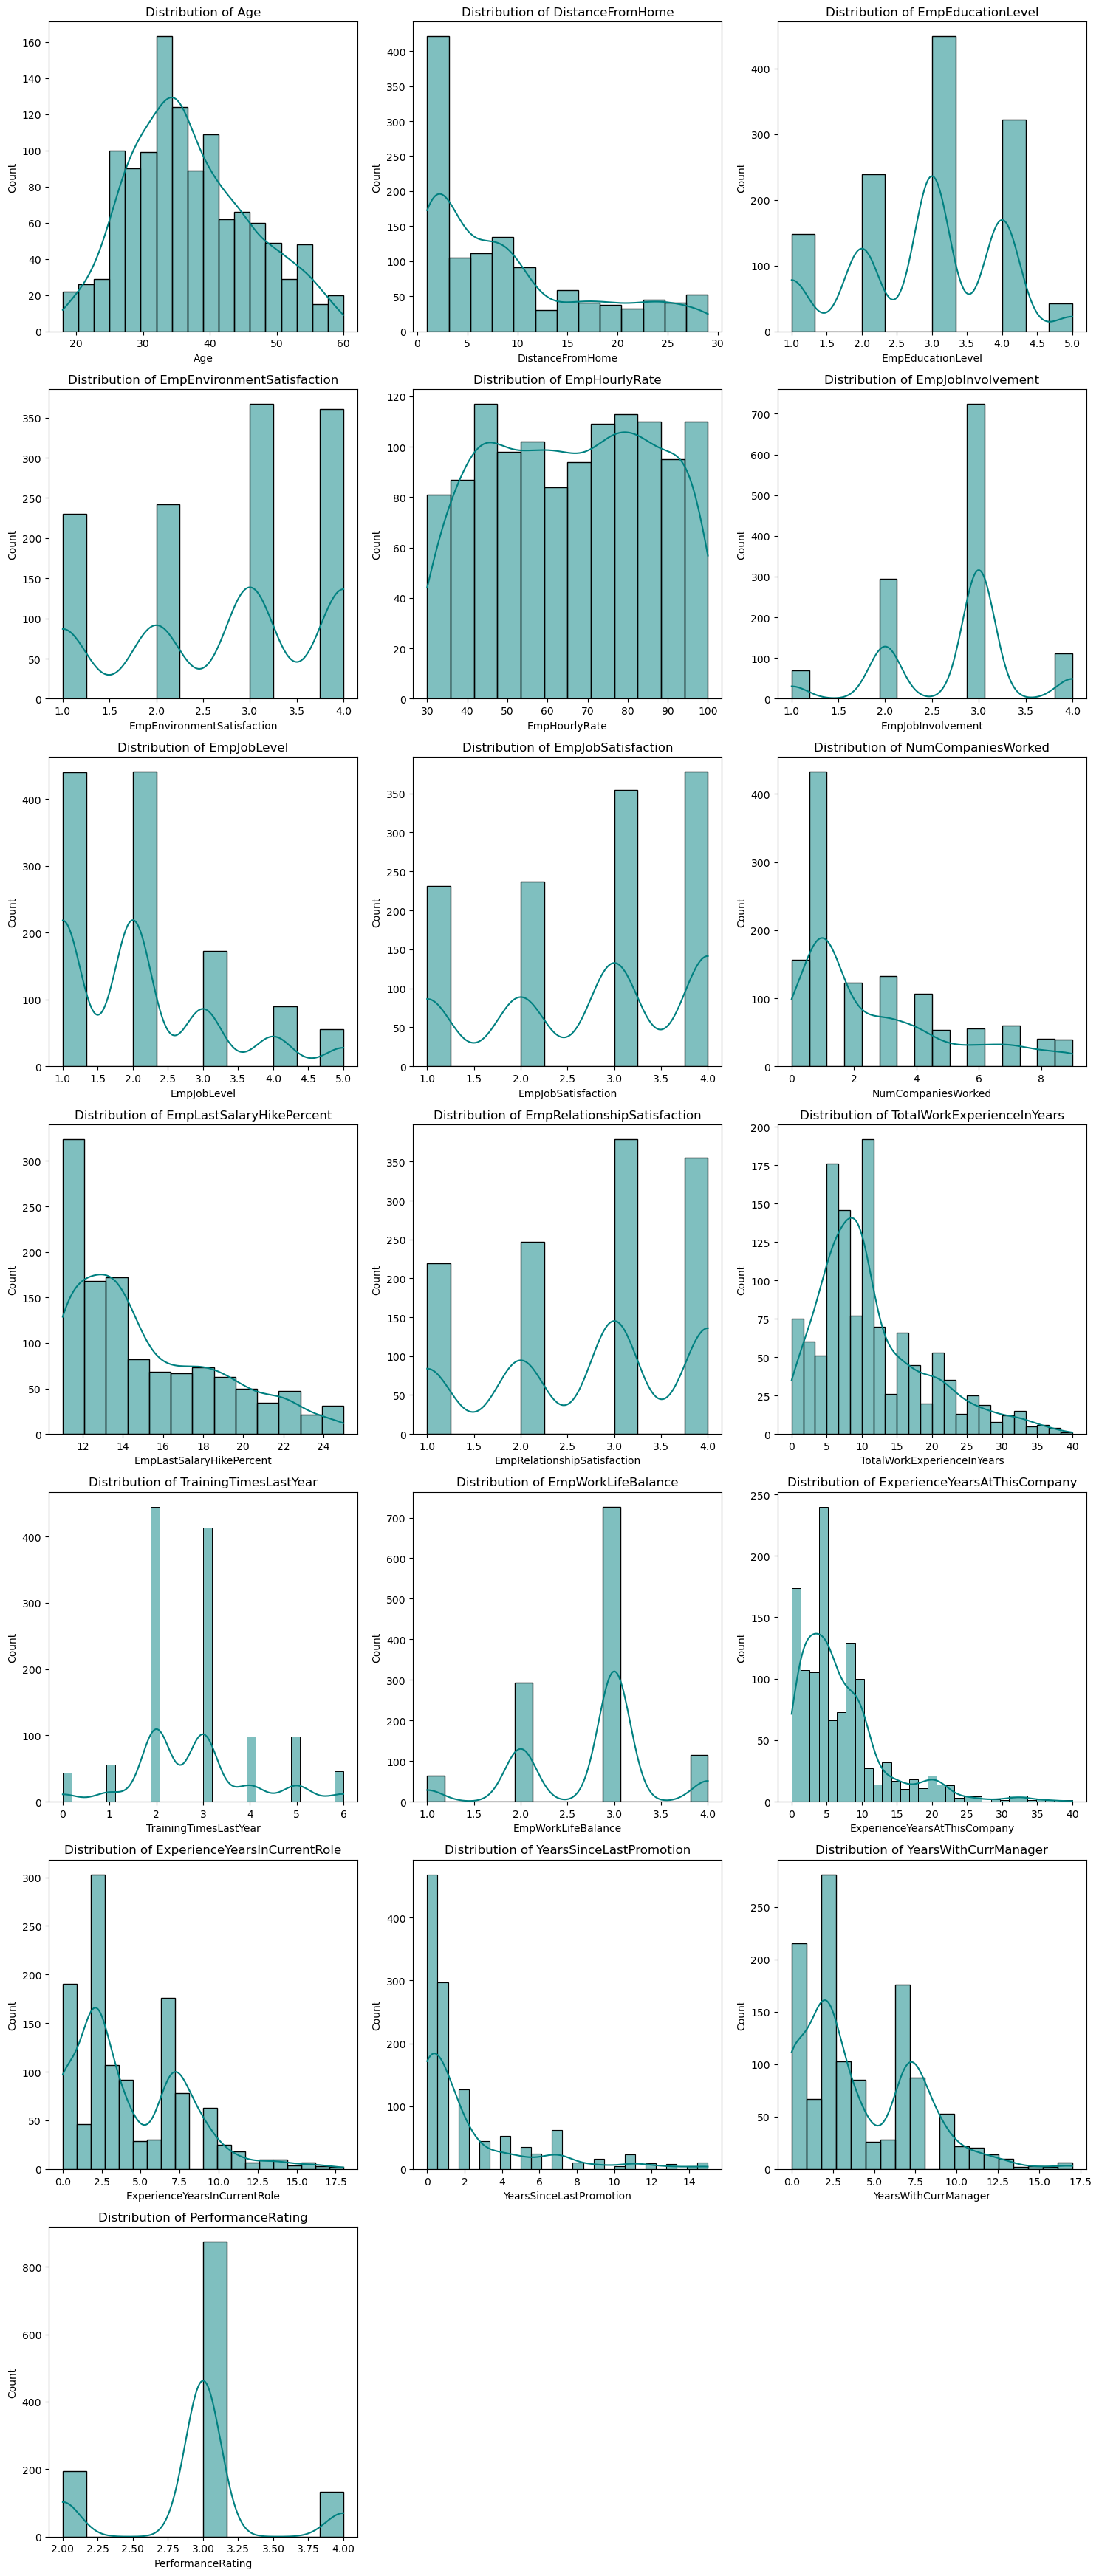

In [34]:
# ==========UNIVARIATE ANALYSIS OF NUMERICAL FEATURE ==============
num_cols = data.select_dtypes(include='number').columns

# Define grid size: 3 columns per row
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data[col], kde=True, color='teal')
    plt.xlabel(col)
    plt.title(f'Distribution of {col}')

plt.tight_layout()

* The average employee age is **36**, with most employees between **25–45 years**
* A majority of employees live close to the workplace
* Most employees rated their job environment as **3.0**
* Employees typically have experience in **0–1 prior companies**
* Salary hikes are mostly within the **0–12% range**
* The most common performance rating is **3**

#### CHART - 2

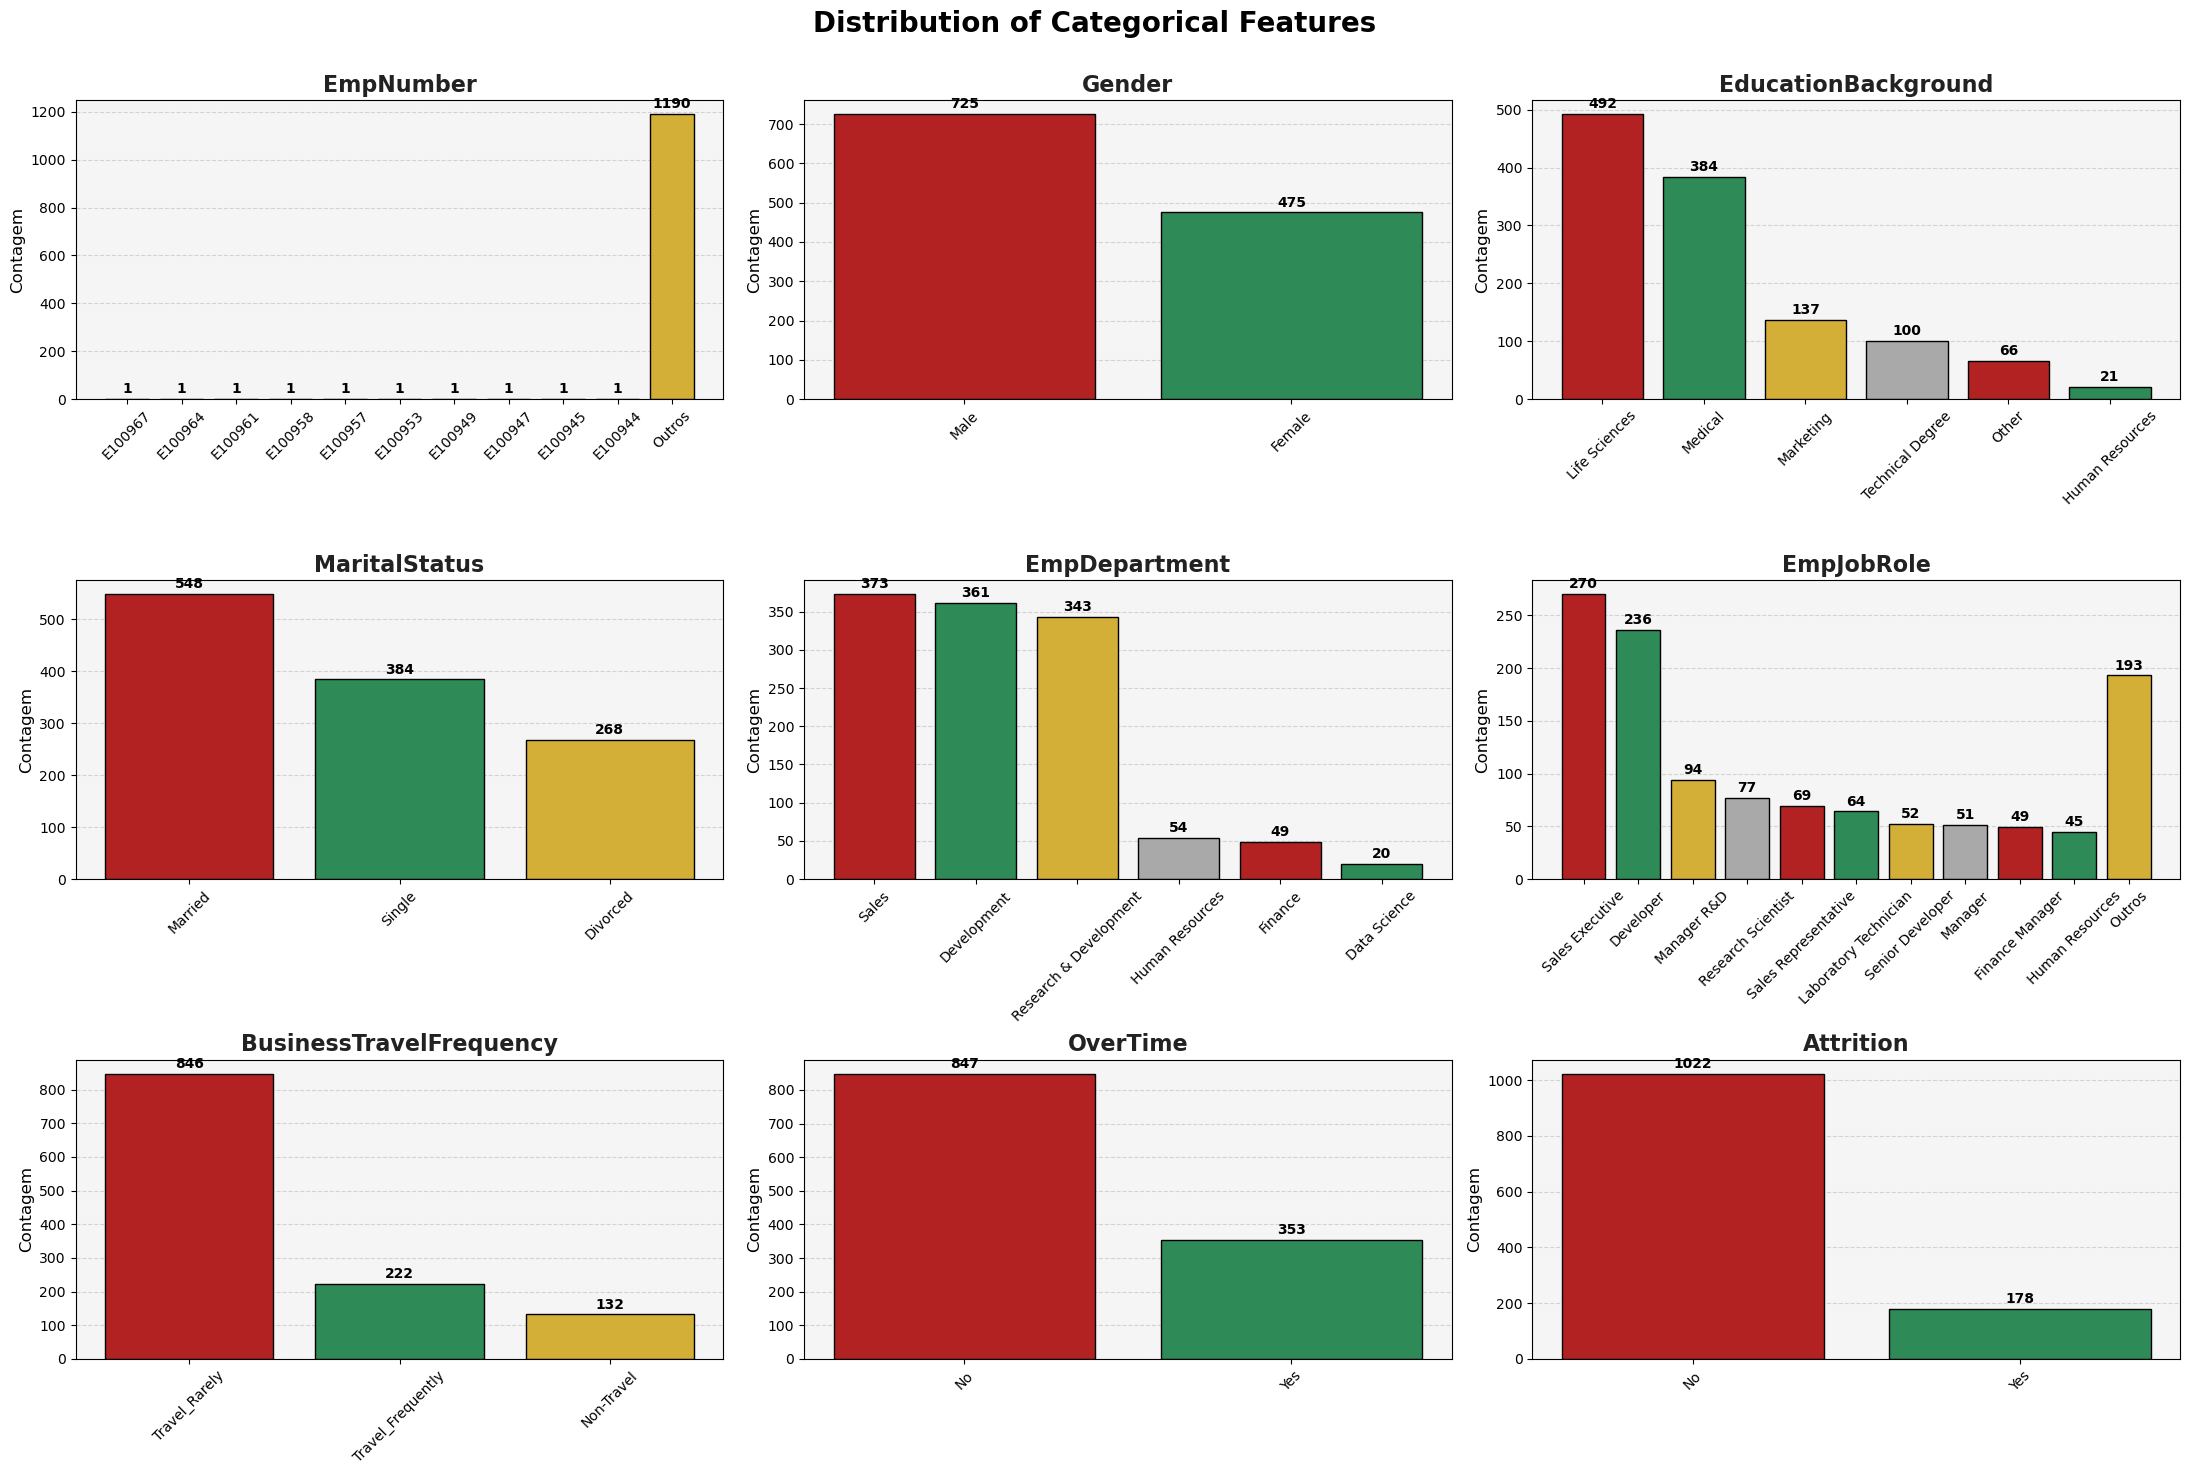

In [35]:
#==== Univariant analysis of categorical feature =====

categorical_cols = data.select_dtypes(include='object').columns

# ==== Subplot grid ====
n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 5*n_rows))
axes = axes.flatten()

# ==== Add main title ====
fig.suptitle('Distribution of Categorical Features',
             fontsize=20, fontweight='bold', y=0.98)

# ==== Color Palette ====
colors = ['#B22222', '#2E8B57', '#D4AF37', '#A9A9A9']

# ==== Background color ====
bg_color = '#F5F5F5'

# ==== Loop through categorical columns ====
for i, col in enumerate(categorical_cols):
    axes[i].set_facecolor(bg_color)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5, zorder=1)
    axes[i].set_title(f'{col}', fontsize=16, fontweight='bold', color='#222222')
    axes[i].set_ylabel('Contagem', fontsize=12)

    ctab = data[col].value_counts()
    if len(ctab) > 10:
        ctab = ctab.nlargest(10)
        ctab["Outros"] = data[col].value_counts().iloc[10:].sum()

    categories = ctab.index
    values = ctab.values

    # ==== Plot vertical bars ====
    bars = axes[i].bar(categories, values,
                       color=[colors[j % len(colors)] for j in range(len(categories))],
                       edgecolor='black', zorder=2)

    # ==== Add raw counts above bars ====
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + max(values)*0.01,
                     f"{val}", ha='center', va='bottom', fontsize=10, fontweight='bold')

    axes[i].tick_params(axis='x', rotation=45, labelsize=10)

# ==== Remove empty subplots ====
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

##  Key Insights (Categorical Features)

####  Gender

* Male employees (~60%) dominate → **gender imbalance**


####  Education Background

* **Life Sciences & Medical** dominate
* HR & Others are very low → **domain concentration**


####  Marital Status

* Majority are **Married**, then Single
* Divorced group is smaller → typical workforce trend


####  Department

* **Sales, Development, R&D** have highest employees
* **Data Science & Finance** are very small → niche teams


####  Job Role

* **Sales Executive & Developer** are top roles
* Many roles have very low count → **role imbalance**


####  Business Travel

* Most employees **rarely travel**
* Frequent travel is limited → low travel dependency


####  OverTime

* Majority **do NOT work overtime**
* But a significant minority does → potential stress group


####  Attrition

* Very high **No (retained)** vs low **Yes (left)**
* Dataset is **imbalanced** → important for ML models 

#### CHART - 3

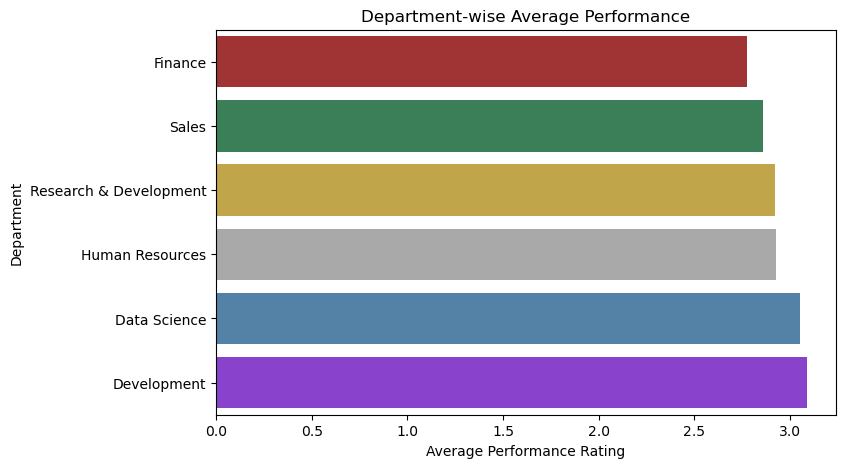

In [36]:
# ========= Deparatement wise Performance Analysis ===========
# Multivariate EDA
# A new pandas Dataframe is created to analyze department wise performance as asked.
# Finding out the mean performance of all the departments and plotting its bar graph using seaborn.
dept_perf = data.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values()

# Plot
colors = ['#B22222', '#2E8B57', '#D4AF37', '#A9A9A9', '#4682B4', '#8A2BE2']
plt.figure(figsize=(8,5))
sns.barplot(x=dept_perf.values, y=dept_perf.index,palette=colors)

plt.title("Department-wise Average Performance")
plt.xlabel("Average Performance Rating")
plt.ylabel("Department")

plt.show()

## Insights: Department-wise Average Performance

####  Key Points

* **Development (~3.1)** → Highest performing department
* **Data Science (~3.0)** → Strong performance despite small team
* **R&D & HR (~2.9–3.0)** → Stable, consistent
* **Sales (~2.85)** → Slightly lower performance
* **Finance (~2.8)** → Lowest among all

####  Interpretation

* Technical teams (**Dev, DS**) perform better
* Business/support teams (**Sales, Finance**) lag slightly
* Differences are **small → overall stable organization**

#### CHART - 4

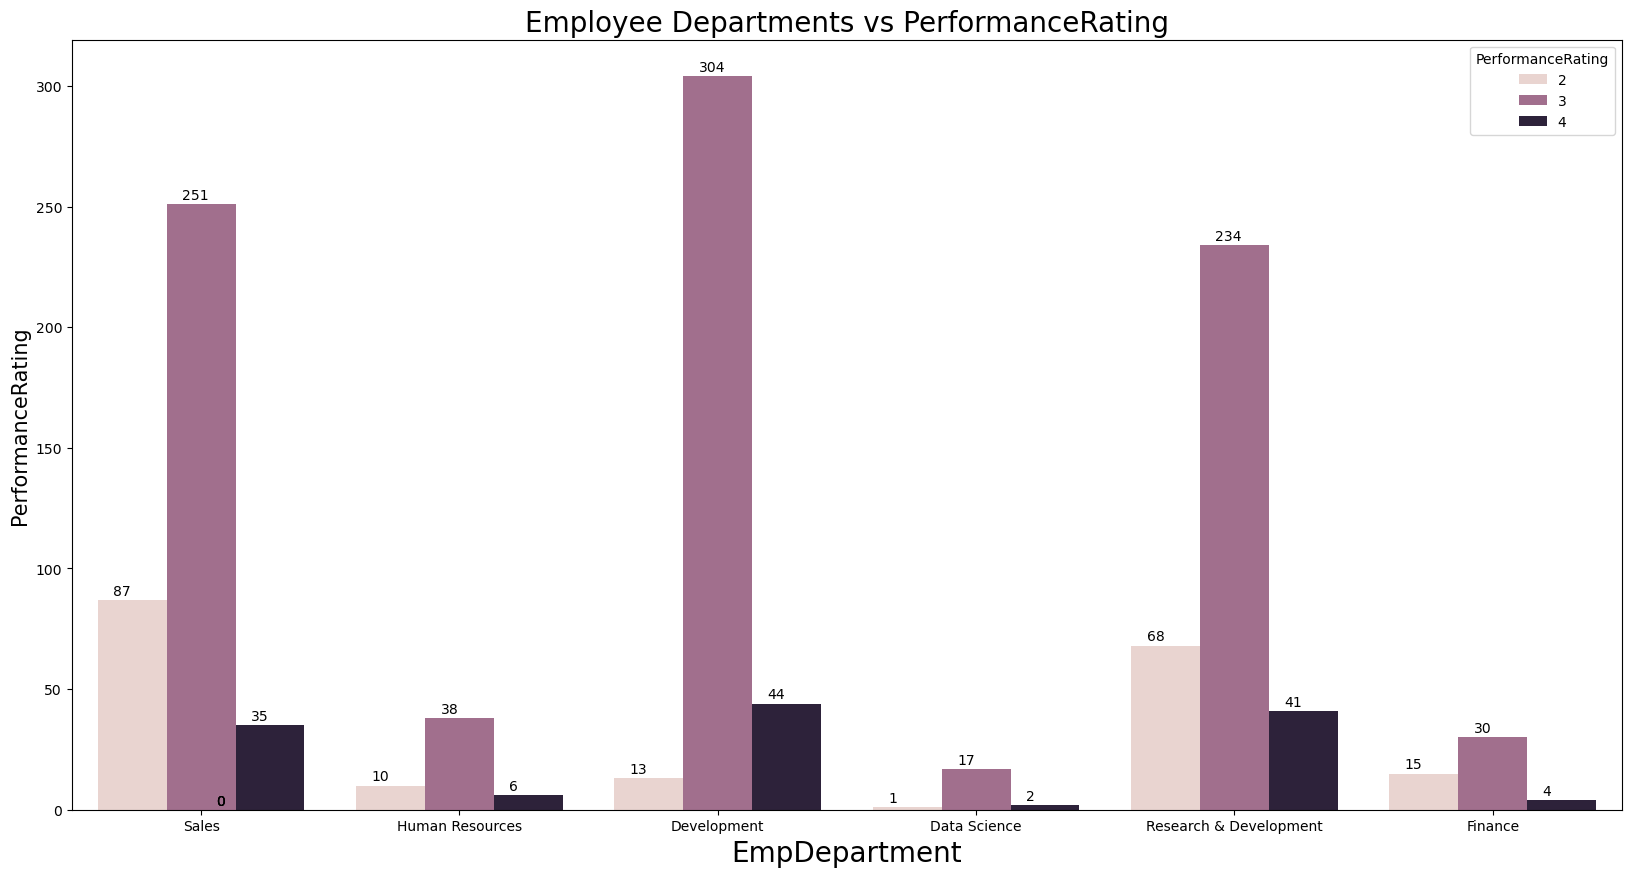

In [37]:
# =============  Plotting a separate bar graph for performance of each department using seaborn (excluding PerformanceRating) ============
plt.figure(figsize=(20,10),facecolor='white')
ax = sns.countplot(x='EmpDepartment',hue=data.PerformanceRating,data=data)
for i in ax.patches:
    ax.annotate('{:.0f}'.format(i.get_height()), (i.get_x()+0.06, i.get_height()+2))
plt.title('Employee Departments vs PerformanceRating',fontsize=20)
plt.xlabel('EmpDepartment',fontsize=20)
plt.ylabel('PerformanceRating',fontsize=15)
plt.show()


#### OBSERVATION:
**From the above graph we can conclude that from the EmpDepartment Development department is showing High performance rating.**

**Sales:** The Performace rating level 3 is more in the sales department. The male performance rating the little bit higher compared to female.

**Human Resources:** The majority of the employees lying under the level 3 performance . The older people are performing low in this department. The female employees in HR department doing really well in their performance.

**Development:** The maximum number of employees are level 3 performers. Employees of all age are performing at the level of 3 only. The gender-based performance is nearly same for both.

**Data Science:** The highest average of level 3 performance is in data science department. Data science is the only department where less number of level 2 performers. The overall performance is higher compared to all departments. Male employees are doing good in this department.

**Research & Development:** The age factor is not deviating from the level of performance here where different employees with different age are there in every level of performance. The R&D has the good female employees in their performance.

**Finance:** The finance department performance is exponentially decreasing when age increases. The male employees are doing good. The experience factor is inversely relating to the performance level.

#### CHART - 5

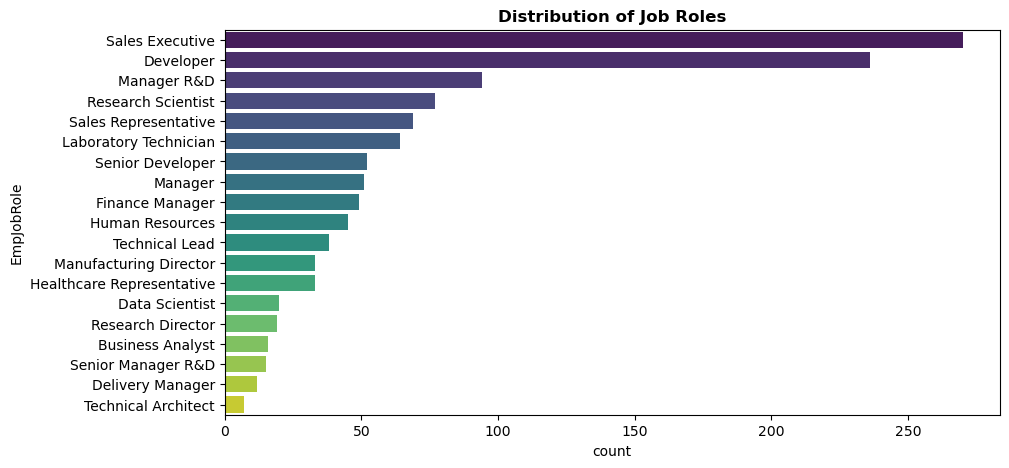

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.countplot(
    y='EmpJobRole',
    data=data,
    order=data['EmpJobRole'].value_counts().index,
    palette='viridis'   # try: 'coolwarm', 'magma', 'Set2', 'cubehelix'
)

plt.title('Distribution of Job Roles', fontweight='bold')
plt.show()

* Descriptive statistics summarize the distribution of *PerformanceRating* (mean, spread, variability).
* A histogram visualizes the overall distribution of performance ratings.
* A boxplot highlights variations and differences in ratings across departments.
* The bar plot shows job role distribution, with *Sales Executive* and *Developer* as dominant roles.
* Roles like *Technical Architect* and *Delivery Manager* are underrepresented, indicating imbalance.
* This imbalance may impact model learning and predictions.
* A word cloud highlights the most frequent job roles visually.
* Overall, these visuals help understand both the target variable and feature distribution.

#### CHART - 6

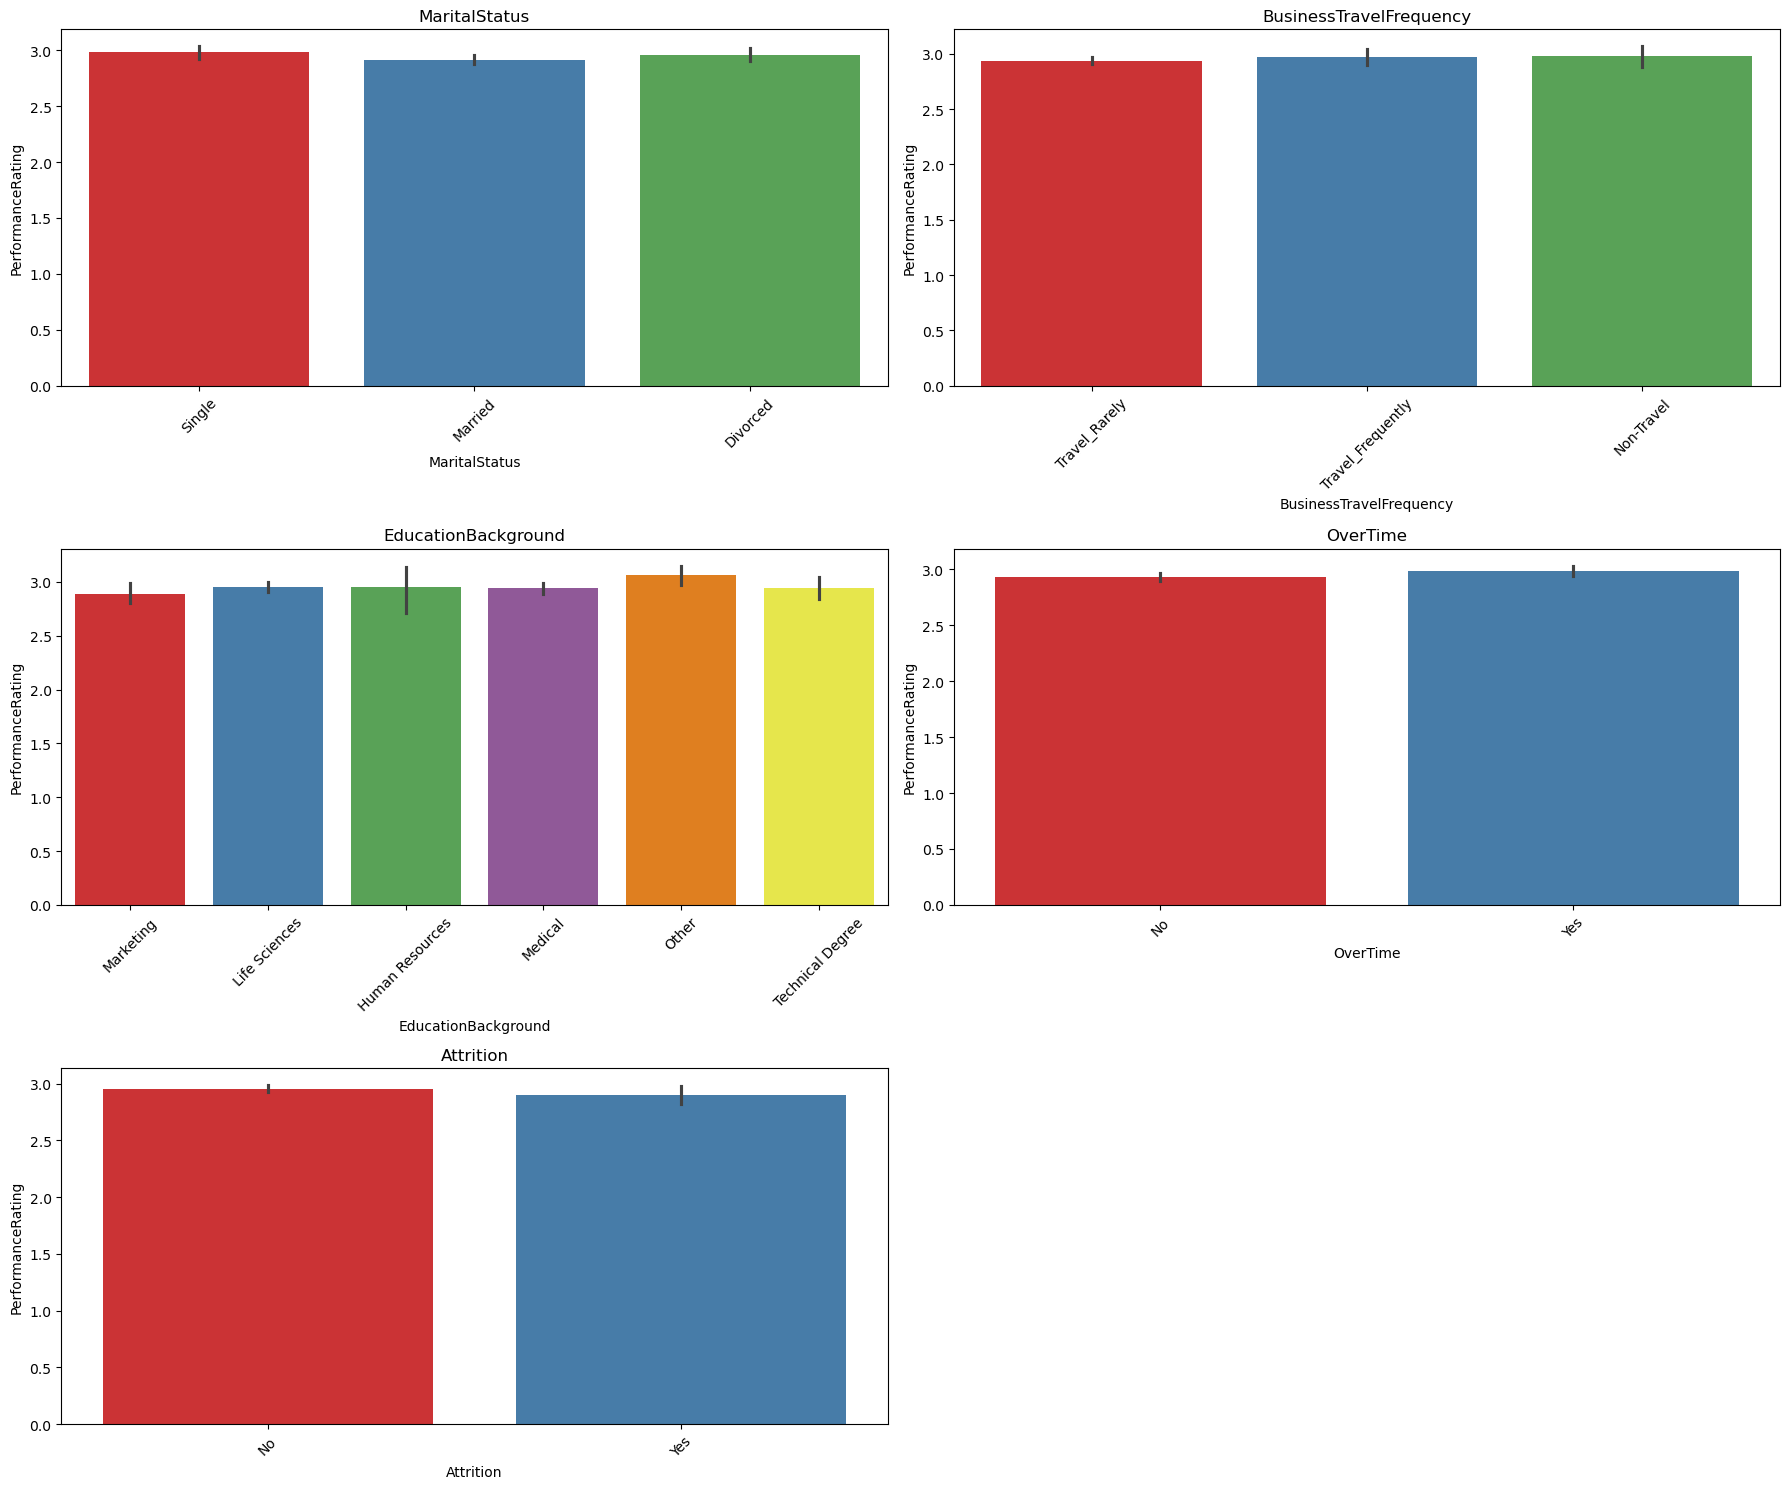

In [39]:
cols = ['MaritalStatus', 'BusinessTravelFrequency',
        'EducationBackground', 'OverTime', 'Attrition']

n_cols = 2
n_rows = (len(cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.barplot(
        x=col,
        y='PerformanceRating',
        data=data,
        ax=axes[i],
        palette='Set1'
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Performance does not vary with marital status, but employees who work overtime tend to have slightly better ratings than those who do not.

#### CHART - 7

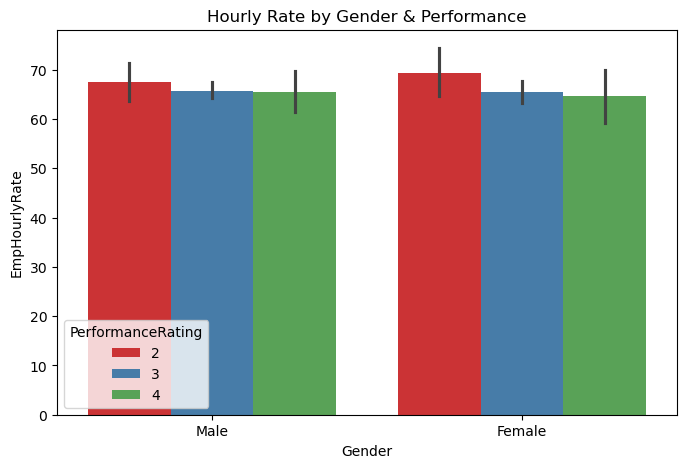

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Gender',
    y='EmpHourlyRate',
    hue='PerformanceRating',
    data=data,
    palette='Set1'
)
plt.title("Hourly Rate by Gender & Performance")
plt.show()

Hourly rate is similar across genders, with only slight variation by performance rating, indicating no strong pay difference based on gender or performance.

#### CHART - 8

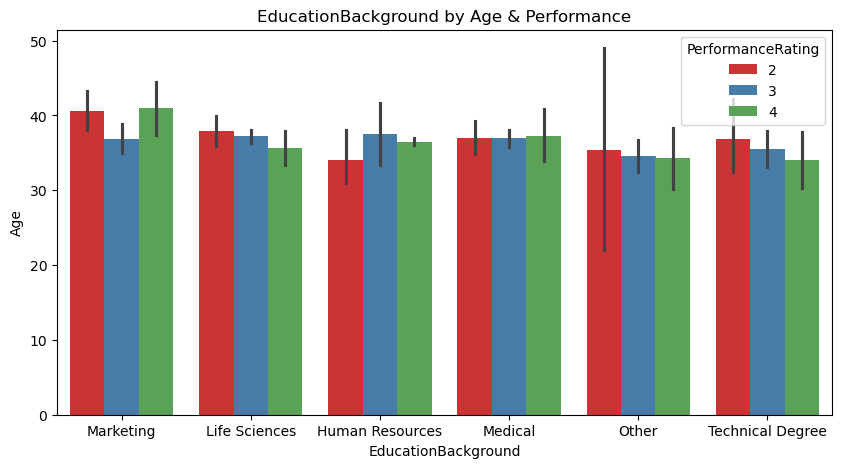

In [42]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='EducationBackground',
    y='Age',
    hue='PerformanceRating',
    data=data,
    palette='Set1'
)
plt.title("EducationBackground by Age & Performance")
plt.show()

Age has minimal impact on performance overall, but some categories show slight variation, with high diversity in the “Other” group.

#### CHART - 9

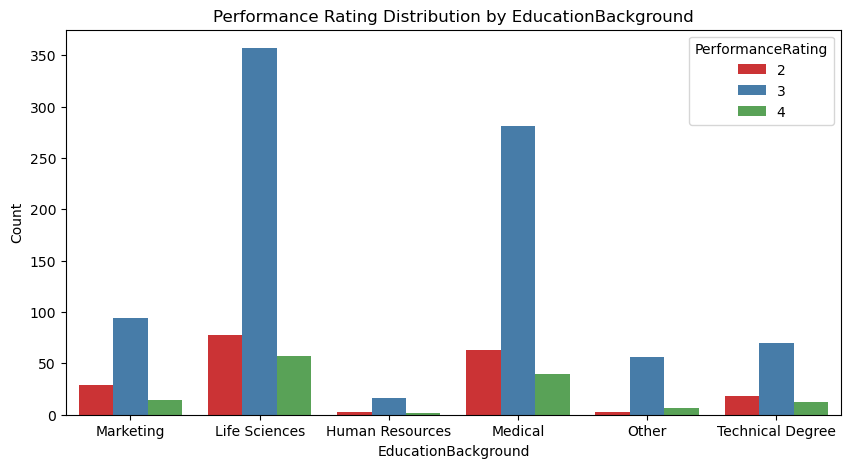

In [43]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='EducationBackground',
    hue='PerformanceRating',
    data=data,
    palette='Set1'
)

plt.title("Performance Rating Distribution by EducationBackground")
plt.xlabel("EducationBackground")
plt.ylabel("Count")

plt.show()

Performance rating 3 dominates across all education backgrounds, especially in Life Sciences and Medical, indicating most employees fall into the average performance category.


#### CHART - 10

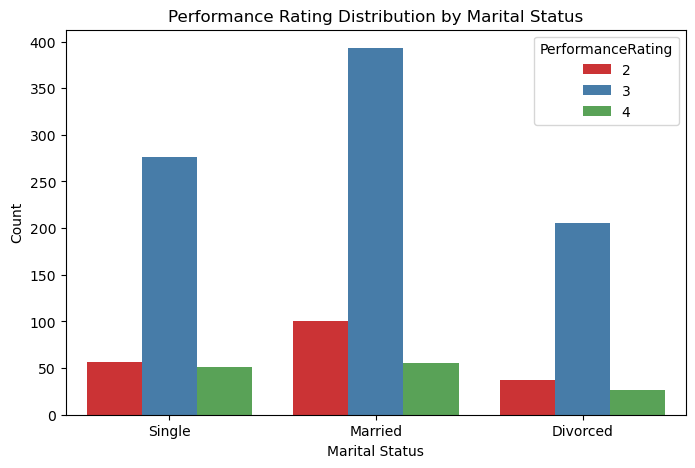

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='MaritalStatus',
    hue='PerformanceRating',
    data=data,
    palette='Set1'
)

plt.title("Performance Rating Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Count")

plt.show()

Across all marital groups, most employees fall into performance rating 3, with married employees having the highest overall count.

#### CHART - 11

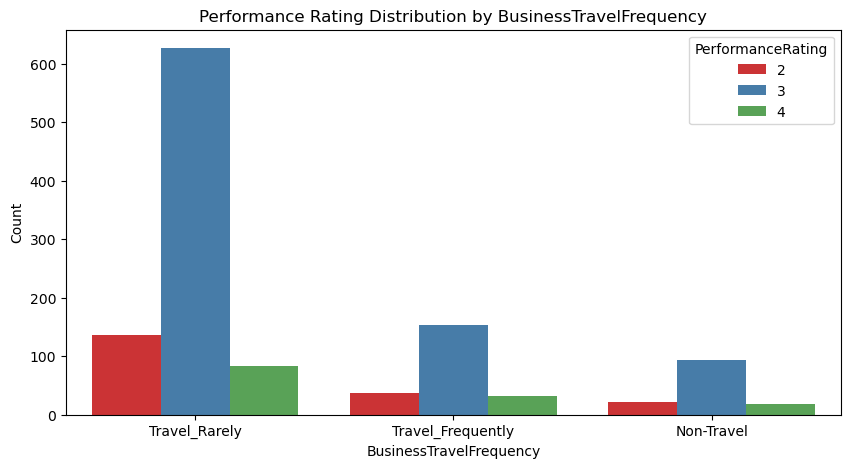

In [45]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='BusinessTravelFrequency',
    hue='PerformanceRating',
    data=data,
    palette='Set1'
)

plt.title("Performance Rating Distribution by BusinessTravelFrequency")
plt.xlabel("BusinessTravelFrequency")
plt.ylabel("Count")

plt.show()

Employees who travel rarely have the highest number of average performers (rating 3), while frequent and non-travel groups show similar but lower patterns.

#### CHART - 12

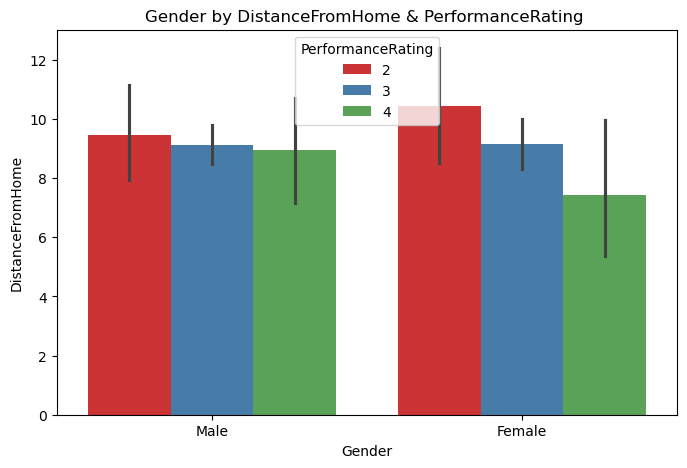

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Gender',
    y='DistanceFromHome',
    hue='PerformanceRating',
    data=data,
    palette='Set1',
)

plt.title("Gender by DistanceFromHome & PerformanceRating ")
plt.xlabel("Gender")
plt.ylabel("DistanceFromHome")

plt.show()

Distance from home is similar across genders, with only slight variation across performance ratings.

#### CHART - 13

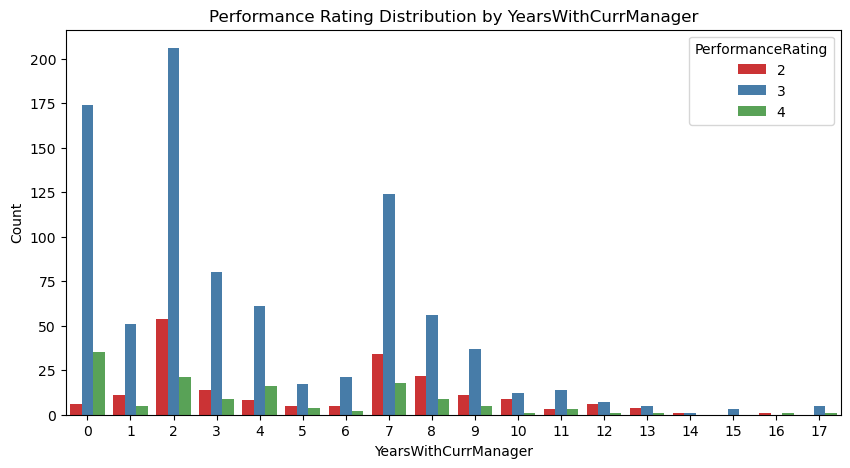

In [47]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='YearsWithCurrManager',
    hue='PerformanceRating',
    data=data,
    palette='Set1'
)

plt.title("Performance Rating Distribution by YearsWithCurrManager")
plt.xlabel("YearsWithCurrManager")
plt.ylabel("Count")

plt.show()

Employees with fewer years under the current manager are more concentrated in performance rating 3, with counts declining as tenure increases.

#### CHART - 14

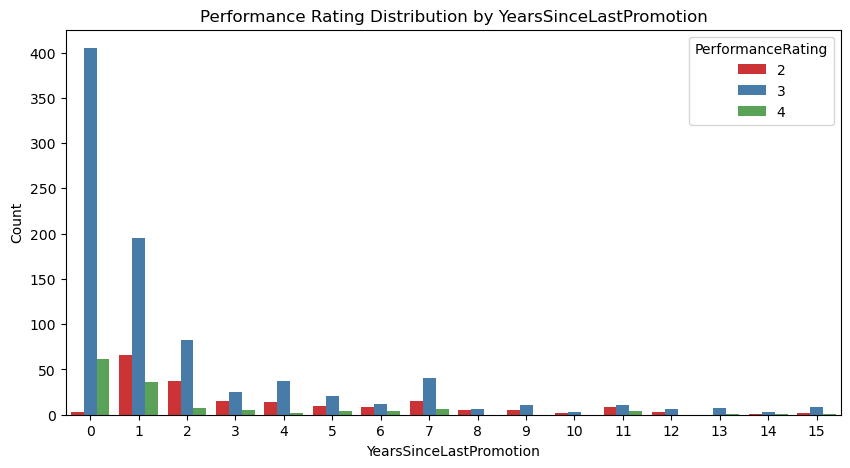

In [48]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='YearsSinceLastPromotion',
    hue='PerformanceRating',
    data=data,
    palette='Set1'
)

plt.title("Performance Rating Distribution by YearsSinceLastPromotion")
plt.xlabel("YearsSinceLastPromotion")
plt.ylabel("Count")

plt.show()

Employees with fewer years since their last promotion are more concentrated in performance rating 3, with overall counts decreasing as the gap since promotion increases.


#### CHART - 15

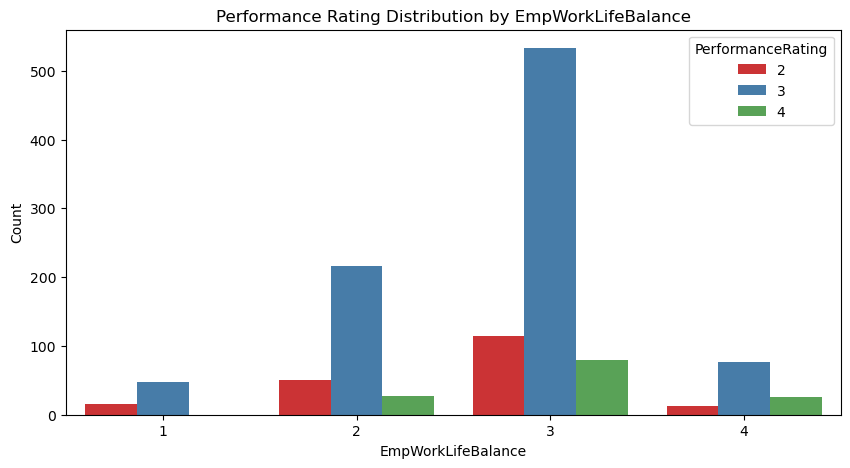

In [49]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='EmpWorkLifeBalance',
    hue='PerformanceRating',
    data=data,
    palette='Set1'
)

plt.title("Performance Rating Distribution by EmpWorkLifeBalance")
plt.xlabel("EmpWorkLifeBalance")
plt.ylabel("Count")

plt.show()

Employees with a moderate work-life balance (level 3) show the highest concentration in performance rating 3, indicating balanced conditions align with average performance.

#### CHART - 16

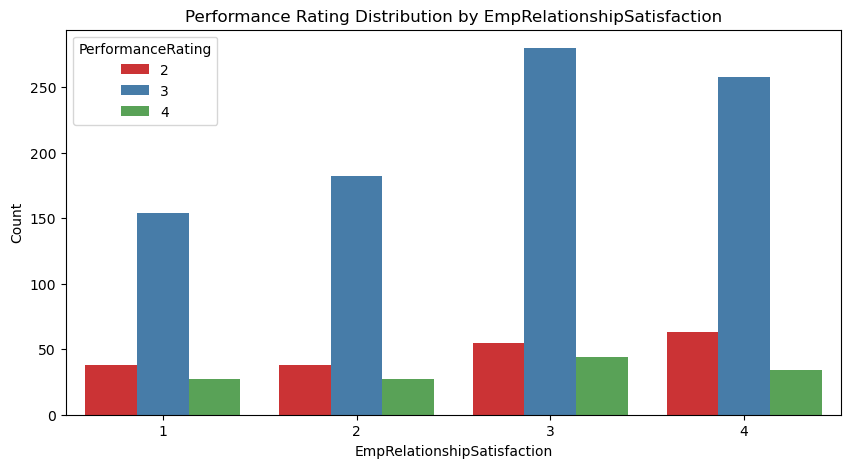

In [50]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='EmpRelationshipSatisfaction',
    hue='PerformanceRating',
    data=data,
    palette='Set1'
)

plt.title("Performance Rating Distribution by EmpRelationshipSatisfaction")
plt.xlabel("EmpRelationshipSatisfaction")
plt.ylabel("Count")

plt.show()

Employees with higher relationship satisfaction levels show a stronger concentration in performance rating 3, indicating better workplace relationships align with stable performance.

#### CHART - 17

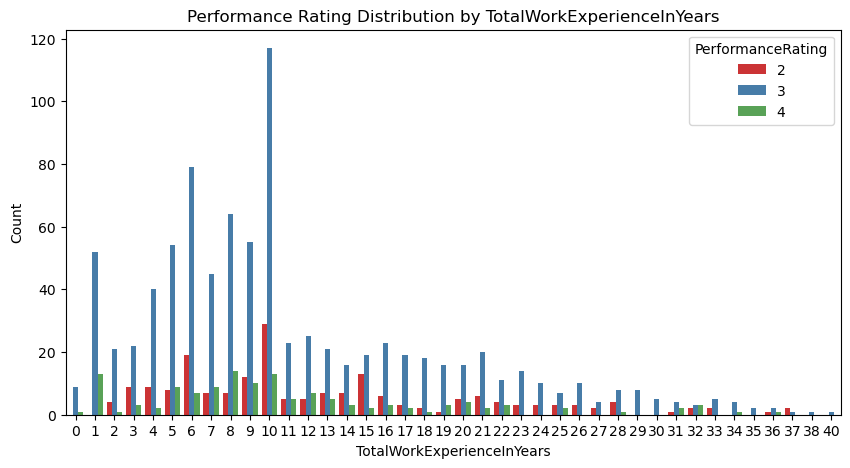

In [51]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='TotalWorkExperienceInYears',
    hue='PerformanceRating',
    data=data,
    palette='Set1'
)

plt.title("Performance Rating Distribution by TotalWorkExperienceInYears")
plt.xlabel("TotalWorkExperienceInYears")
plt.ylabel("Count")

plt.show()

When total work experience of employee is **above 10 year the performace of employee drops**

#### CHART - 18

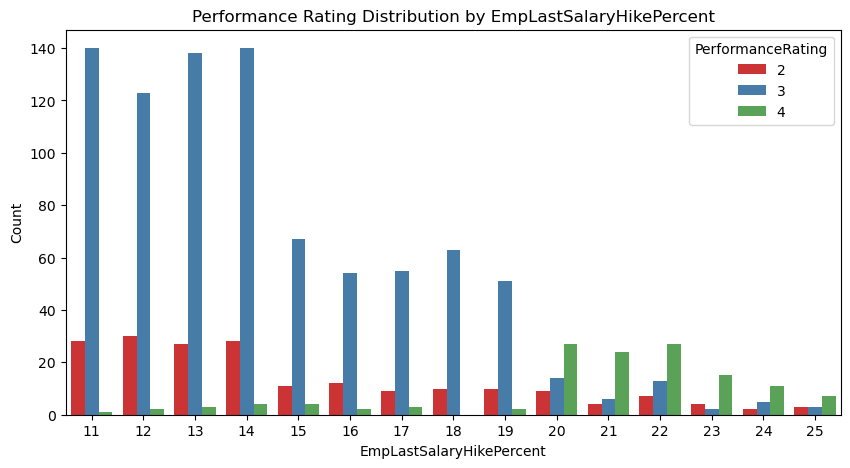

In [52]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='EmpLastSalaryHikePercent',
    hue='PerformanceRating',
    data=data,
    palette='Set1'
)

plt.title("Performance Rating Distribution by EmpLastSalaryHikePercent")
plt.xlabel("EmpLastSalaryHikePercent")
plt.ylabel("Count")

plt.show()

When the employee got **salary hike of more than 19%, the performance of employee increased.** Thus, employee performance depends on the salary hike given by the company. Employee with higher salary hike percentage has performed well.

| Feature                    | Value | Description   |
| -------------------------- | ----- | ------------- |
| PerformanceRating          | 1     | Low           |
|                            | 2     | Good          |
|                            | 3     | Excellent     |
|                            | 4     | Outstanding   |

#### CHART - 19

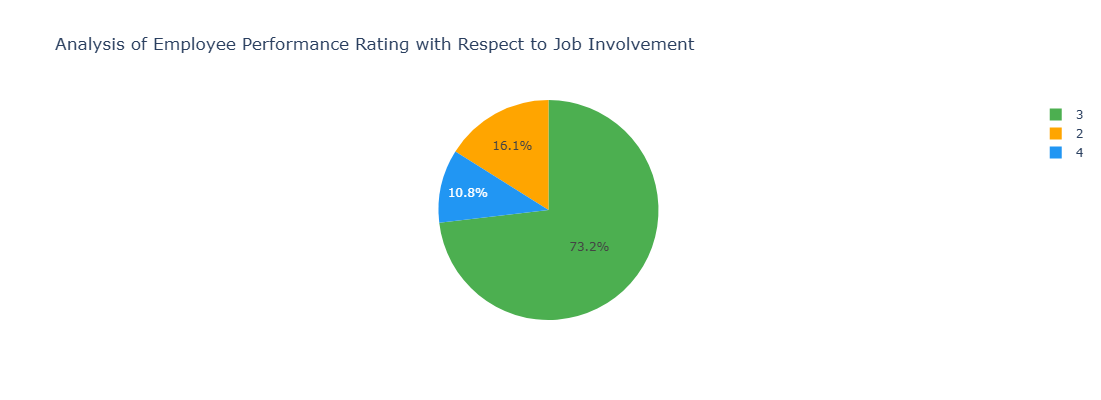

In [53]:
import plotly.express as px


fig = px.pie(
    data_frame=data,
    names='PerformanceRating',
    values='EmpJobInvolvement',
    color='PerformanceRating',  
    color_discrete_map={
        1: '#FF4C4C',   # Low
        2: '#FFA500',   # Good
        3: '#4CAF50',   # Excellent
        4: '#2196F3'    # Outstanding
    },
    title='Analysis of Employee Performance Rating with Respect to Job Involvement',
    width=750, height=400
)

fig.show()

Most employees are rated 3 (~73%), indicating average performance dominates, while smaller portions fall into lower (16.1%) and higher (10.8%) ratings.

#### CHART - 20

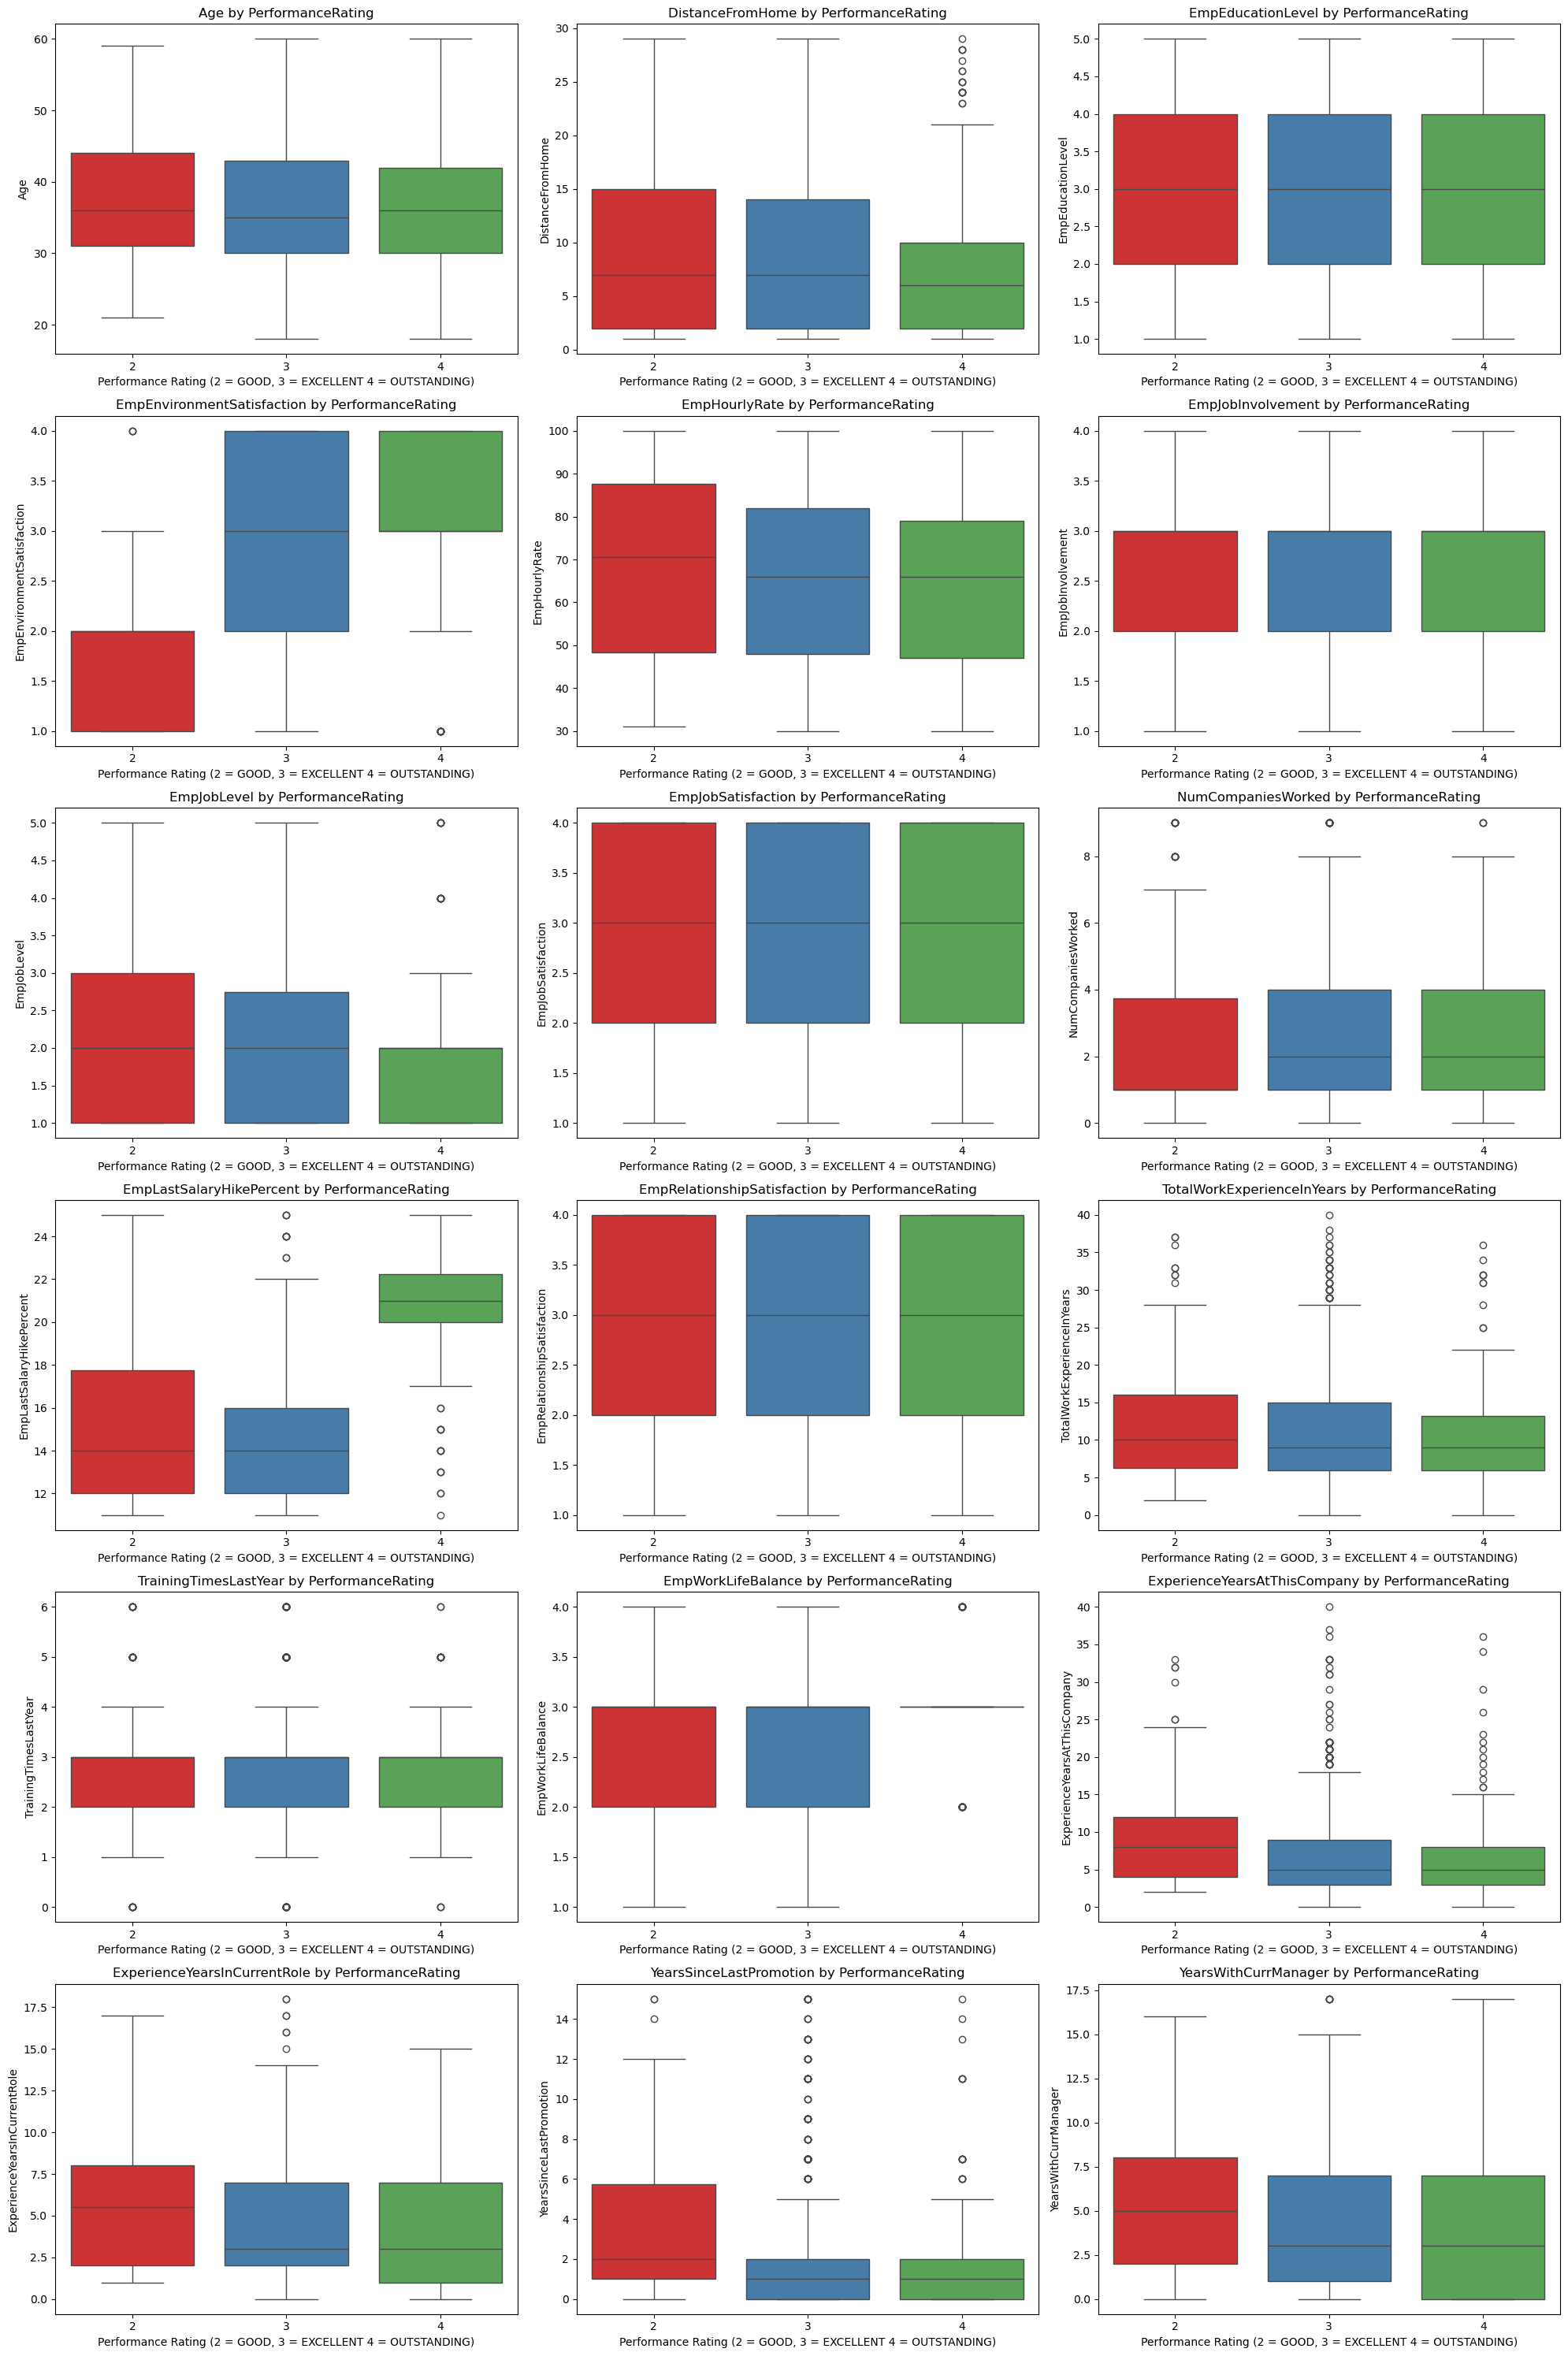

In [54]:
#======Visualization of Boxplot: Checking for the Outliers=======

import math

# Select numerical columns (exclude target)
num_cols = data.select_dtypes(include='number').columns.drop('PerformanceRating')

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(
        data=data,
        x="PerformanceRating",
        y=col,
        palette="Set1"
    )

    plt.title(f"{col.replace('_', ' ')} by PerformanceRating")
    plt.xlabel("Performance Rating (2 = GOOD, 3 = EXCELLENT 4 = OUTSTANDING)")

plt.tight_layout()
plt.show()


This set of boxplots is used to compare the distribution of numerical features between PerformanceRating. It helps identify differences in median values, data spread, and outliers for each feature across the three classes.

#### CHART - 21

In [55]:
# ===================== for the temporary label encoding =======================
from sklearn.preprocessing import LabelEncoder
temp_data = data.copy()
cat_cols=['Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'OverTime',
       'Attrition']
encoder = LabelEncoder()
# Loop through the columns in cat_cols1 and apply LabelEncoder
for col in cat_cols:
    temp_data[col] = encoder.fit_transform(temp_data[col])

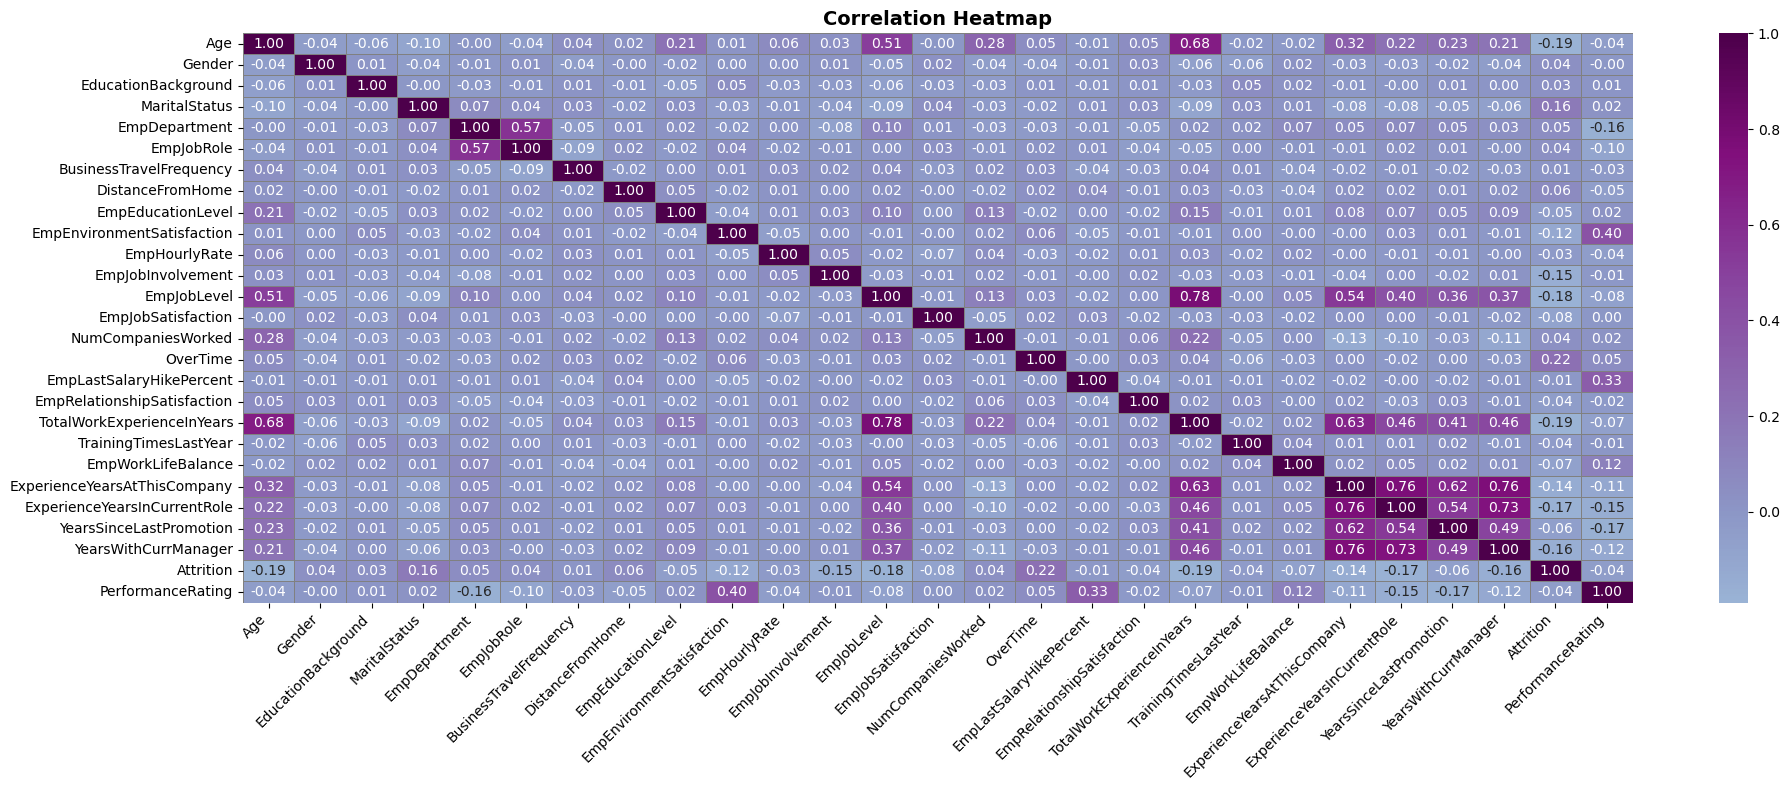

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop unnecessary column (safe check)
if 'EmpNumber' in temp_data.columns:
    temp_data = temp_data.drop('EmpNumber', axis=1)

# Correlation matrix
corr = temp_data.corr()

plt.figure(figsize=(20, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='BuPu',
    linewidths=0.5,
    linecolor='gray',
    center=0
)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### **OBSERVATION IN CORRELATION**
##### **Strong Positive Correlations (r > 0.70)**

| Feature 1                    | Feature 2               | Correlation (r) | Interpretation                                   |
| ---------------------------- | ----------------------- | --------------- | ------------------------------------------------ |
| TotalWorkExperienceInYears   | EmpJobLevel             | **0.78**        | Higher experience strongly increases job level   |
| ExperienceYearsAtThisCompany | YearsWithCurrManager    | **0.76**        | Longer tenure → longer reporting to same manager |
| ExperienceYearsAtThisCompany | YearsSinceLastPromotion | **0.62–0.76**   | Promotions linked with tenure                    |
| YearsWithCurrManager         | YearsInCurrentRole      | **0.73**        | Stability in role & management                   |

---

#### **Moderate Positive Correlations (0.40 – 0.70)**

| Feature 1                  | Feature 2                  | Correlation (r) | Interpretation                        |
| -------------------------- | -------------------------- | --------------- | ------------------------------------- |
| Age                        | TotalWorkExperienceInYears | **0.68**        | Older employees have more experience  |
| TotalWorkExperienceInYears | YearsAtCompany             | **0.63**        | Experience aligns with company tenure |
| EmpJobLevel                | YearsAtCompany             | **0.54**        | Higher level → longer stay            |
| NumCompaniesWorked         | Age                        | **0.28**        | Slight relation with job switches     |

---

#### **Correlation with PerformanceRating**

##### **Positive Correlations**

| Feature                    | Correlation (r) | Interpretation                          |
| -------------------------- | --------------- | --------------------------------------- |
| EmpEnvironmentSatisfaction | **0.40**        | Better environment → higher performance |
| EmpLastSalaryHikePercent   | **0.33**        | Salary hike linked with performance     |
| EmpWorkLifeBalance         | **0.12**        | Slight positive impact                  |

---

#####  **Negative Correlations**

| Feature                      | Correlation (r) | Interpretation                              |
| ---------------------------- | --------------- | ------------------------------------------- |
| YearsSinceLastPromotion      | **-0.17**       | Delayed promotions reduce performance       |
| ExperienceYearsAtThisCompany | **-0.11**       | Longer stay may reduce performance slightly |
| Attrition                    | **-0.04**       | Very weak negative relation                 |

---

#### **Weak / No Significant Correlations**

Most features (Gender, EducationBackground, DistanceFromHome, etc.) show **near-zero correlation** with performance.

**Indicates:**

```text
PerformanceRating is influenced by multiple factors, not a single strong predictor
```

#### **Key Insight Summary:**

* Strong multicollinearity exists among **experience-related features**
* These should be **handled carefully (drop/reduce) for linear models**
* Performance is **moderately influenced by satisfaction & salary factors**
* No single dominant feature → **justifies using ensemble models (Random Forest)**

The correlation analysis reveals strong relationships among experience-based features and moderate influence of satisfaction-related variables on performance, while most features show weak correlation, indicating the need for robust models to capture complex patterns.


In [57]:
# =========== Employee last salary hike percent ==============
pd.crosstab(data['EmpLastSalaryHikePercent'],data['PerformanceRating'],margins=True)

PerformanceRating,2,3,4,All
EmpLastSalaryHikePercent,,,,
11,28,140,1,169
12,30,123,2,155
13,27,138,3,168
14,28,140,4,172
15,11,67,4,82
16,12,54,2,68
17,9,55,3,67
18,10,63,0,73
19,10,51,2,63


In [58]:
# ================= Employee Work life balance ===================
pd.crosstab(data['EmpWorkLifeBalance'],data['PerformanceRating'],margins=True)

PerformanceRating,2,3,4,All
EmpWorkLifeBalance,,,,
1,16,48,0,64
2,51,216,27,294
3,115,533,79,727
4,12,77,26,115
All,194,874,132,1200


In [59]:
# ================= Employee job Role ===================
pd.crosstab(data['EmpJobRole'],data['PerformanceRating'],margins=True)

PerformanceRating,2,3,4,All
EmpJobRole,,,,
Business Analyst,0,13,3,16
Data Scientist,1,17,2,20
Delivery Manager,0,12,0,12
Developer,6,199,31,236
Finance Manager,15,30,4,49
Healthcare Representative,8,22,3,33
Human Resources,9,31,5,45
Laboratory Technician,14,45,5,64
Manager,12,29,10,51


In [60]:
percent = pd.crosstab(data["PerformanceRating"], data["EmpDepartment"], margins=True,normalize=True)
round(percent.multiply(100),2)

EmpDepartment,Data Science,Development,Finance,Human Resources,Research & Development,Sales,All
PerformanceRating,,,,,,,
2,0.08,1.08,1.25,0.83,5.67,7.25,16.17
3,1.42,25.33,2.50,3.17,19.50,20.92,72.83
4,0.17,3.67,0.33,0.50,3.42,2.92,11.00
All,1.67,30.08,4.08,4.50,28.58,31.08,100.00


So from the below data we got clear indication of those employees who have low performance, low job involvement and have less or equal to 2 years of experience.

In [61]:
# ==== Filtering those employees whose performance rating is low but working in this company for less or equal to 2 years ====
low_per=data.loc[(data['PerformanceRating']==2) & (data['Attrition']=='No')& (data['EmpJobInvolvement']<= 2)& 
                 (data['ExperienceYearsAtThisCompany'] <= 2),['EmpNumber','ExperienceYearsAtThisCompany',
                                                              'EmpJobInvolvement','Attrition','PerformanceRating']]
low_per

,EmpNumber,ExperienceYearsAtThisCompany,EmpJobInvolvement,Attrition,PerformanceRating
165,E1001300,2,2,No,2
182,E1001322,2,2,No,2
605,E1002079,2,2,No,2
728,E1002291,2,2,No,2
878,E100461,2,2,No,2
1023,E100702,2,2,No,2


As per Goal-2, the identified low-performing employees should be further evaluated and provided with targeted support, training, or performance improvement plans.